# Confronto Locale vs Cluster AWS EMR — Flight Delay Analysis

Questo notebook confronta i risultati ottenuti in **esecuzione locale** (Mac, single-node con Hive embedded + Spark local mode) con quelli ottenuti su **cluster AWS EMR** (3 nodi m5.xlarge: 1 master + 2 core, emr-7.8.0, YARN).

Il confronto si articola in tre parti:
1. **Tempi di esecuzione**: scalabilità al variare della dimensione del dataset, speedup cluster vs locale
2. **Correttezza dei risultati**: verifica che i risultati del cluster siano identici a quelli locali (al 100%)
3. **Considerazioni finali**: quando conviene il cluster, overhead di setup, trade-off

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

matplotlib.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

# Root del progetto: funziona sia se Jupyter è avviato dalla root sia da comparisons/
_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == 'comparisons' else _cwd
assert (ROOT / 'benchmarks' / 'benchmarks.csv').exists(), (
    f"Root del progetto non trovata in {ROOT}. "
    "Avvia Jupyter dalla cartella flight-delay-bigdata1/ o dalla sotto-cartella comparisons/.")

CHARTS_DIR = Path('charts')
CHARTS_DIR.mkdir(exist_ok=True)

COLORS  = {'Hive':'#E67E22','Spark_SQL':'#2980B9','Spark_Core':'#8E44AD','MapReduce':'#27AE60'}
MARKERS = {'Hive':'o','Spark_SQL':'s','Spark_Core':'^','MapReduce':'D'}

print(f'ROOT: {ROOT}')
print(f'CHARTS_DIR: {CHARTS_DIR.resolve()}')
print('Setup completato ✓')

ROOT: /Users/camillamariasantoro/flight-delay-bigdata1
CHARTS_DIR: /Users/camillamariasantoro/flight-delay-bigdata1/comparisons/charts
Setup completato ✓


## 1. Caricamento dei benchmark

In [2]:
df_loc = pd.read_csv(ROOT / 'benchmarks' / 'benchmarks.csv')
df_clu = pd.read_csv(ROOT / 'benchmarks_cluster' / 'benchmarks_cluster.csv')

for df in [df_loc, df_clu]:
    df['Pct'] = df['Percentuale'].str.replace('%','').astype(int)
    df['Analisi'] = df['Analisi'].astype(str)

df_loc['Ambiente'] = 'Locale'
df_clu['Ambiente'] = 'Cluster'
df_all = pd.concat([df_loc, df_clu], ignore_index=True)

PERCENTUALI = sorted(df_all['Pct'].unique())
ANALISI     = sorted(df_all['Analisi'].unique())
TECNOLOGIE  = sorted(df_all['Tecnologia'].unique())

print(f'Dataset %: {PERCENTUALI}')
print(f'Analisi: {ANALISI}')
print(f'Tecnologie: {TECNOLOGIE}')
print()
print('Benchmark Locale:')
display(df_loc.head(6))
print('Benchmark Cluster:')
display(df_clu.head(6))

Dataset %: [np.int64(10), np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(150)]
Analisi: ['3.1', '3.2', '3.3']
Tecnologie: ['Hive', 'MapReduce', 'Spark_Core', 'Spark_SQL']

Benchmark Locale:


,Percentuale,Analisi,Tecnologia,Tempo_Secondi,Pct,Ambiente
0,10%,3.1,Hive,8,10,Locale
1,10%,3.1,Spark_SQL,6,10,Locale
2,10%,3.1,MapReduce,1,10,Locale
3,10%,3.2,Hive,30,10,Locale
4,10%,3.2,Spark_SQL,7,10,Locale
5,10%,3.2,MapReduce,1,10,Locale


Benchmark Cluster:


,Percentuale,Analisi,Tecnologia,Tempo_Secondi,Pct,Ambiente
0,10%,3.1,Hive,29,10,Cluster
1,10%,3.1,Spark_SQL,28,10,Cluster
2,10%,3.1,MapReduce,33,10,Cluster
3,10%,3.2,Hive,37,10,Cluster
4,10%,3.2,Spark_SQL,34,10,Cluster
5,10%,3.2,MapReduce,32,10,Cluster


## 2. Tabella comparativa dei tempi al 100%

In [3]:
pivot_loc = (
    df_loc[df_loc['Pct']==100]
    .pivot_table(index='Tecnologia', columns='Analisi', values='Tempo_Secondi', aggfunc='first')
    .rename(columns=lambda c: f'A{c}_locale')
)
pivot_clu = (
    df_clu[df_clu['Pct']==100]
    .pivot_table(index='Tecnologia', columns='Analisi', values='Tempo_Secondi', aggfunc='first')
    .rename(columns=lambda c: f'A{c}_cluster')
)

compare = pivot_loc.join(pivot_clu, how='outer')

cols_sorted = []
for a in ANALISI:
    for env in ['locale', 'cluster']:
        col = f'A{a}_{env}'
        if col in compare.columns:
            cols_sorted.append(col)
compare = compare[cols_sorted].copy()

for a in ANALISI:
    lc, cc = f'A{a}_locale', f'A{a}_cluster'
    if lc in compare.columns and cc in compare.columns:
        compare[f'A{a}_speedup'] = (compare[lc] / compare[cc]).round(2)

numeric_cols = [c for c in compare.columns if 'speedup' not in c]
speedup_cols = [c for c in compare.columns if 'speedup' in c]

styled = (compare.style
    .format('{:.0f}', subset=numeric_cols, na_rep='—')
    .format('{:.2f}x', subset=speedup_cols, na_rep='—')
    .background_gradient(cmap='RdYlGn', subset=speedup_cols)
    .set_caption('Tempi (secondi) e speedup al 100% del dataset — verde = cluster più veloce'))
display(styled)

Analisi,A3.1_locale,A3.1_cluster,A3.2_locale,A3.2_cluster,A3.3_locale,A3.3_cluster,A3.1_speedup,A3.2_speedup,A3.3_speedup
Tecnologia,,,,,,,,,
Hive,12,33,38,48,—,—,0.36x,0.79x,—
MapReduce,14,43,21,48,15,48,0.33x,0.44x,0.31x
Spark_Core,—,—,—,—,6,55,—,—,0.11x
Spark_SQL,5,28,11,50,6,28,0.18x,0.22x,0.21x


## 3. Scalabilità: locale vs cluster per tecnologia

/var/folders/0p/sx2q3w3d0n12d_0t4x5g96m80000gn/T/ipykernel_22125/4224853809.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


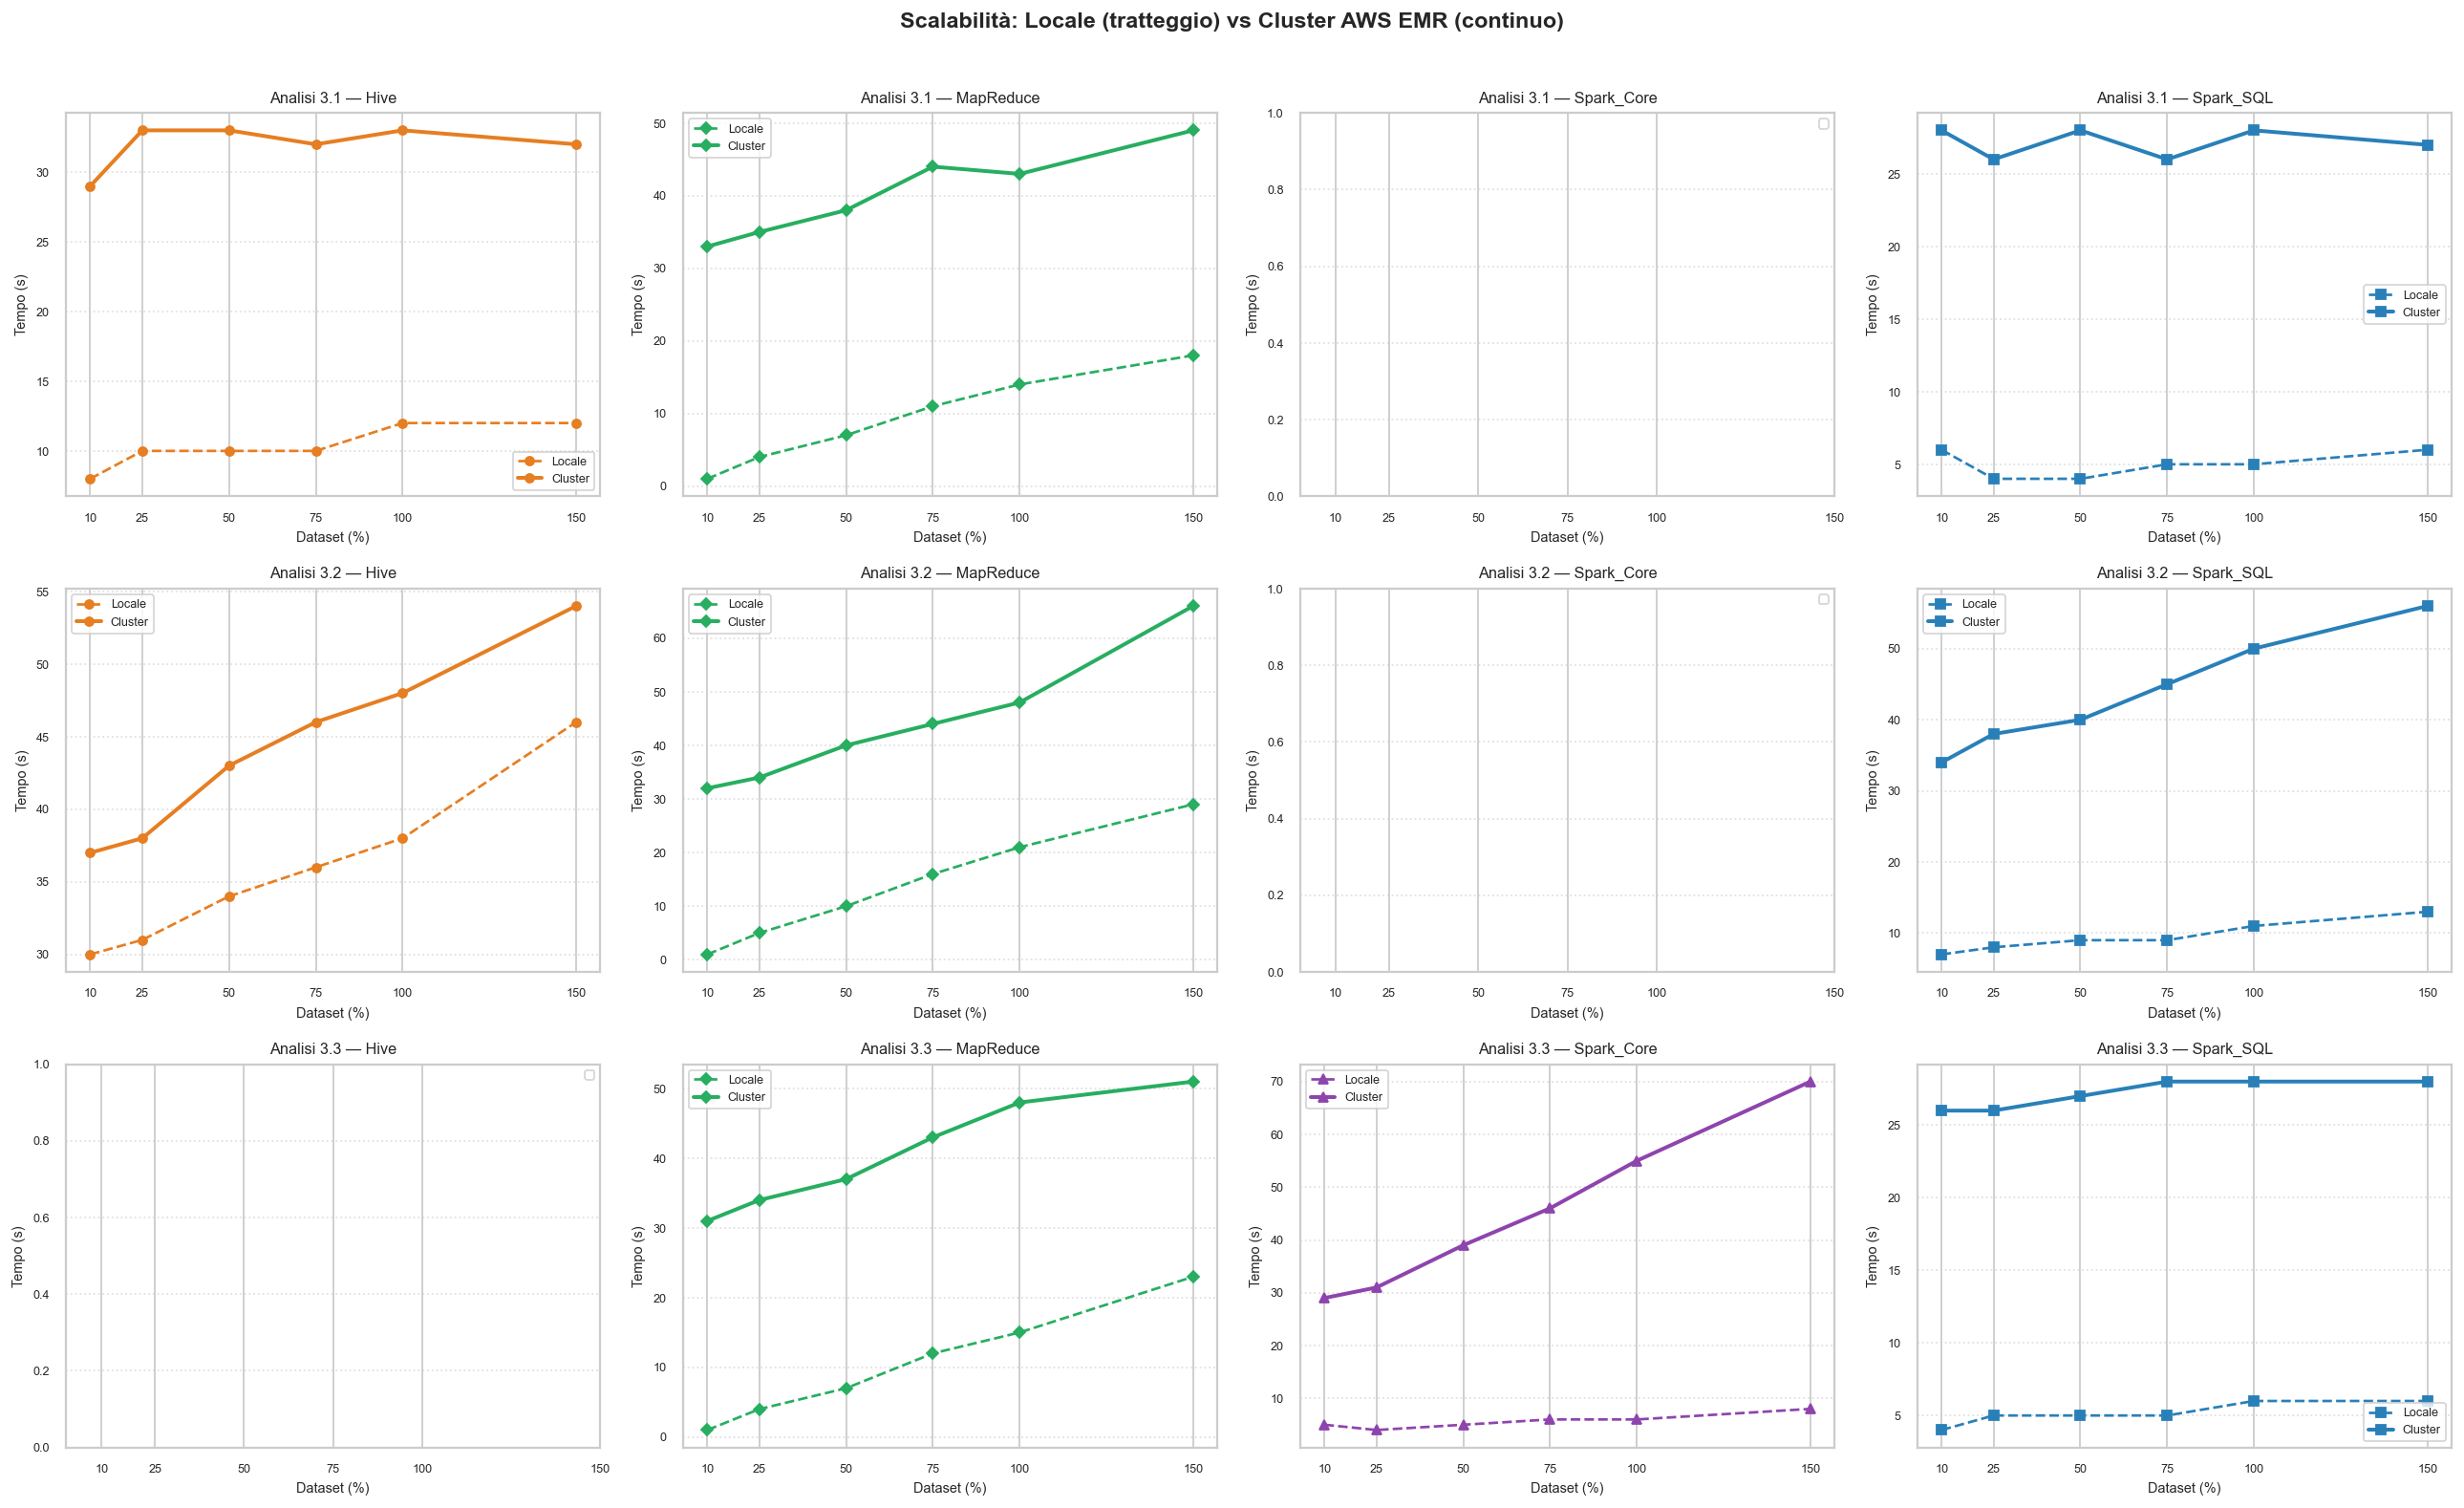

Salvato: charts/scalability_locale_vs_cluster.png


In [4]:
fig, axes = plt.subplots(len(ANALISI), len(TECNOLOGIE),
                         figsize=(5*len(TECNOLOGIE), 4*len(ANALISI)),
                         sharey=False)

if len(ANALISI) == 1:
    axes = [axes]
if len(TECNOLOGIE) == 1:
    axes = [[ax] for ax in axes]

for i, analisi in enumerate(ANALISI):
    for j, tech in enumerate(TECNOLOGIE):
        ax = axes[i][j]
        color = COLORS.get(tech, 'gray')
        for env, ls, lw in [('Locale','--',1.5),('Cluster','-',2.2)]:
            sub = df_all[(df_all['Analisi']==analisi) &
                         (df_all['Tecnologia']==tech) &
                         (df_all['Ambiente']==env)].sort_values('Pct')
            if sub.empty:
                continue
            ax.plot(sub['Pct'], sub['Tempo_Secondi'],
                    color=color, linestyle=ls, linewidth=lw,
                    marker=MARKERS.get(tech,'o'), markersize=5, label=env)
        ax.set_title(f'Analisi {analisi} — {tech}', fontsize=9)
        ax.set_xlabel('Dataset (%)', fontsize=8)
        ax.set_ylabel('Tempo (s)', fontsize=8)
        ax.set_xticks(PERCENTUALI)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(axis='y', linestyle=':', alpha=0.6)

fig.suptitle('Scalabilità: Locale (tratteggio) vs Cluster AWS EMR (continuo)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'scalability_locale_vs_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvato: {CHARTS_DIR}/scalability_locale_vs_cluster.png')

## 4. Confronto diretto al 100%: grouped bar chart

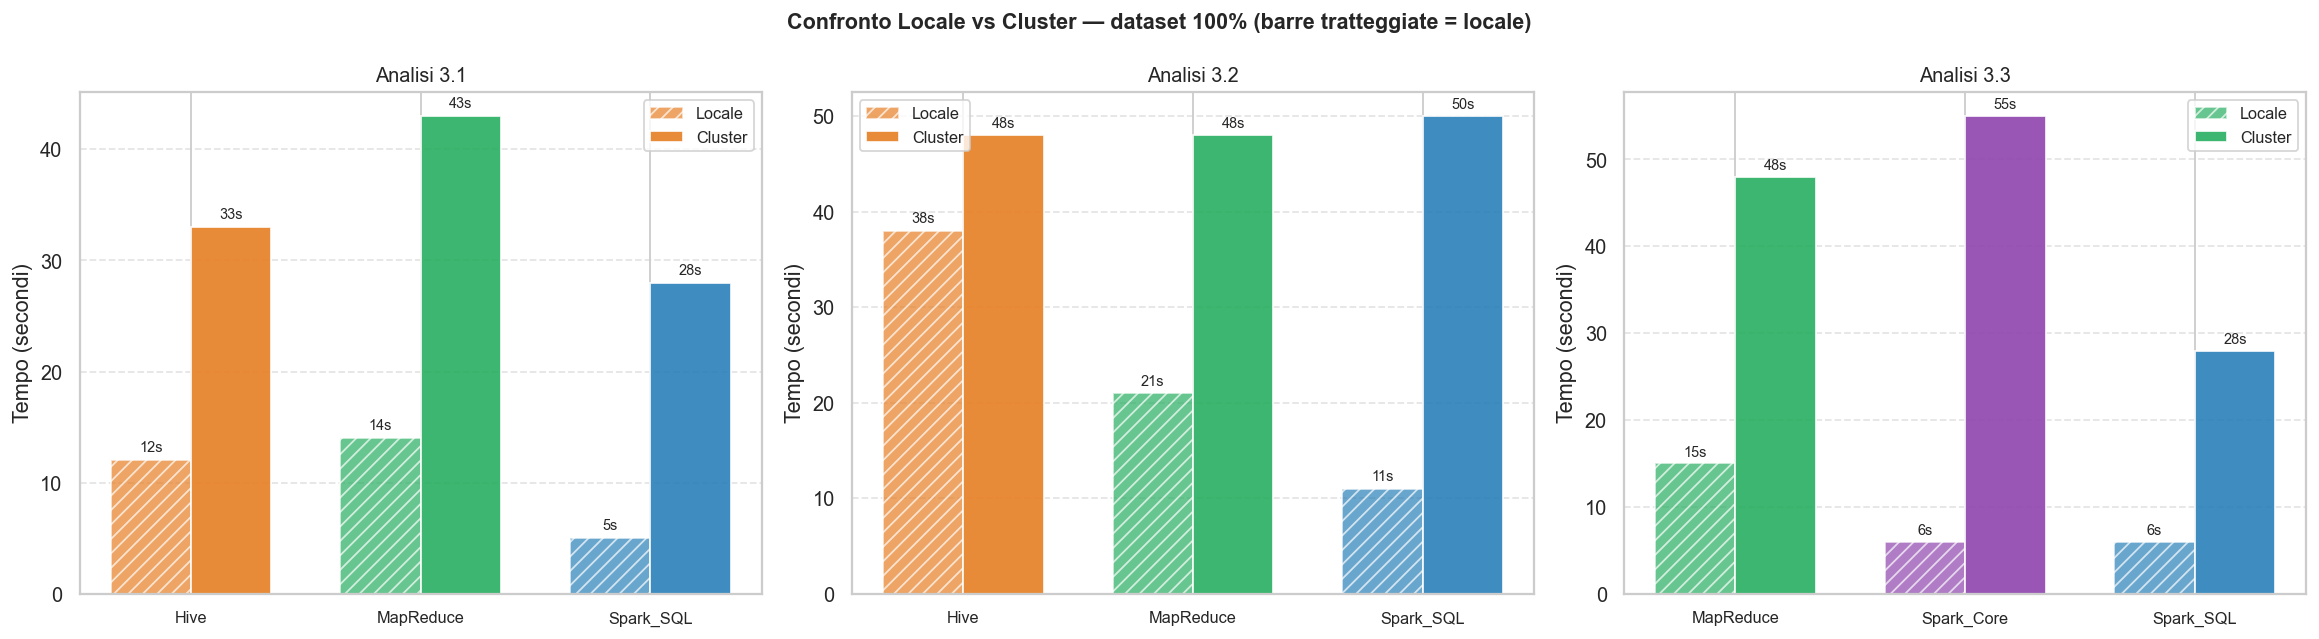

Salvato: charts/comparison_locale_vs_cluster_100pct.png


In [5]:
df100 = df_all[df_all['Pct'] == 100].copy()

fig, axes = plt.subplots(1, len(ANALISI), figsize=(6*len(ANALISI), 5), sharey=False)
if len(ANALISI) == 1:
    axes = [axes]

for idx, analisi in enumerate(ANALISI):
    ax = axes[idx]
    sub = df100[df100['Analisi'] == analisi]
    techs_here = sorted(sub['Tecnologia'].unique())
    x = np.arange(len(techs_here))
    width = 0.35

    for ei, (env, hatch, alpha) in enumerate([('Locale','///',0.7),('Cluster','',0.9)]):
        vals = []
        for t in techs_here:
            row = sub[(sub['Tecnologia']==t) & (sub['Ambiente']==env)]
            vals.append(row['Tempo_Secondi'].values[0] if not row.empty else 0)
        bars = ax.bar(x + (ei-0.5)*width, vals, width,
                      color=[COLORS.get(t,'gray') for t in techs_here],
                      alpha=alpha, hatch=hatch, label=env, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{v:.0f}s', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Analisi {analisi}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(techs_here, fontsize=9)
    ax.set_ylabel('Tempo (secondi)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Confronto Locale vs Cluster — dataset 100% (barre tratteggiate = locale)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'comparison_locale_vs_cluster_100pct.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvato: {CHARTS_DIR}/comparison_locale_vs_cluster_100pct.png')

## 5. Heatmap speedup: cluster / locale

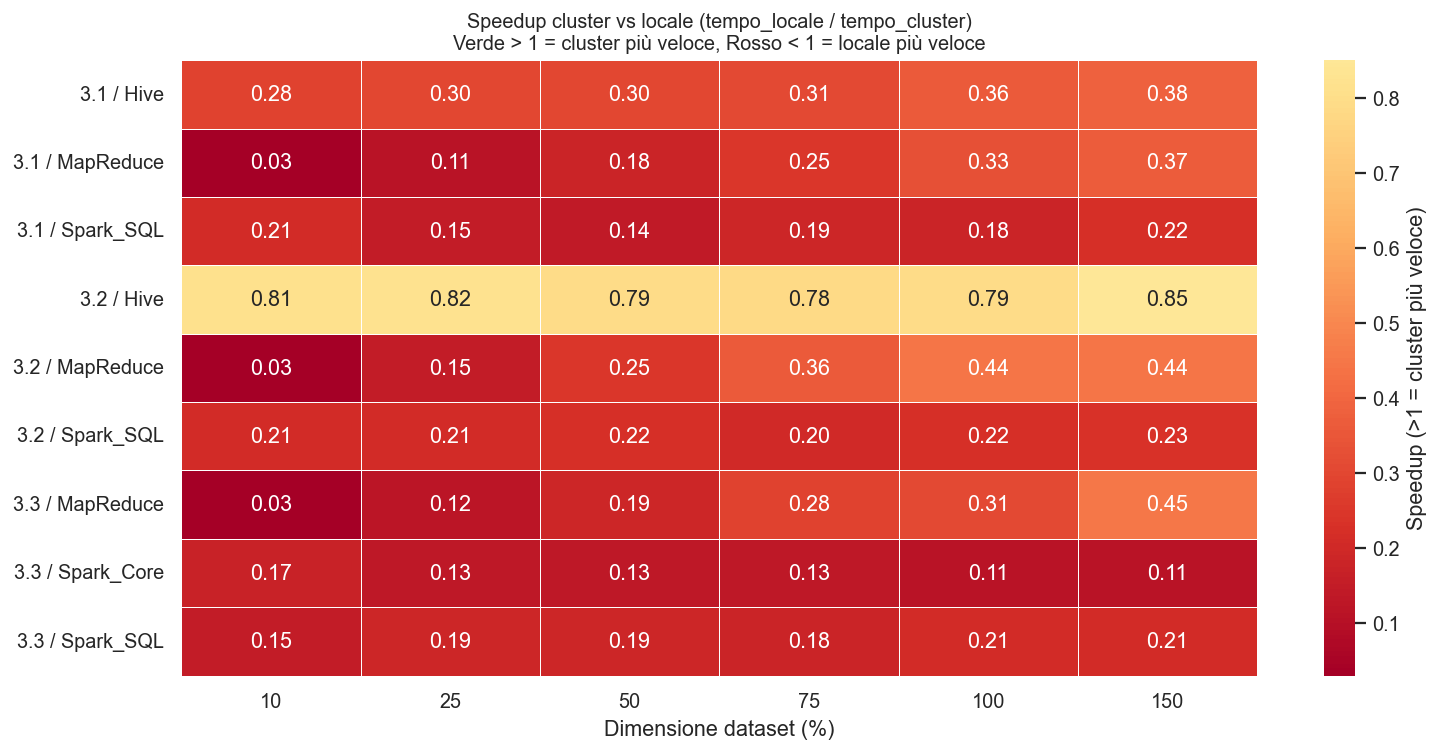

Salvato: charts/heatmap_speedup.png


In [6]:
rows = []
for analisi in ANALISI:
    for tech in TECNOLOGIE:
        for pct in PERCENTUALI:
            loc_row = df_loc[(df_loc['Analisi']==analisi)&(df_loc['Tecnologia']==tech)&(df_loc['Pct']==pct)]
            clu_row = df_clu[(df_clu['Analisi']==analisi)&(df_clu['Tecnologia']==tech)&(df_clu['Pct']==pct)]
            if not loc_row.empty and not clu_row.empty:
                t_loc = loc_row['Tempo_Secondi'].values[0]
                t_clu = clu_row['Tempo_Secondi'].values[0]
                speedup = round(t_loc / t_clu, 2) if t_clu > 0 else np.nan
                rows.append({'Label': f'{analisi} / {tech}', 'Pct': pct, 'Speedup': speedup})

df_sp = pd.DataFrame(rows)
pivot_sp = df_sp.pivot_table(index='Label', columns='Pct', values='Speedup')
pivot_sp = pivot_sp.reindex(sorted(pivot_sp.index))

fig, ax = plt.subplots(figsize=(12, max(4, len(pivot_sp)*0.55+1)))
sns.heatmap(pivot_sp, annot=True, fmt='.2f', cmap='RdYlGn',
            center=1.0, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Speedup (>1 = cluster più veloce)'}, ax=ax)
ax.set_xlabel('Dimensione dataset (%)')
ax.set_ylabel('')
ax.set_title('Speedup cluster vs locale (tempo_locale / tempo_cluster)\n'
             'Verde > 1 = cluster più veloce, Rosso < 1 = locale più veloce', fontsize=11)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'heatmap_speedup.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvato: {CHARTS_DIR}/heatmap_speedup.png')

## 6. Correttezza dei risultati: locale vs cluster

Verifica che i risultati prodotti dal cluster siano **identici** a quelli locali (dataset al 100%). Le eventuali differenze su colonne float sono accettabili entro una tolleranza di arrotondamento (0.01).

In [7]:
RESULT_PAIRS = [
    ('3.1 Hive',
     ROOT/'results/analysis_31/hive/hive_full_results.csv',
     ROOT/'results_cluster/analysis_31/hive/hive_full_results.csv'),
    ('3.1 Spark SQL',
     ROOT/'results/analysis_31/spark_sql/spark_sql_full_results.csv',
     ROOT/'results_cluster/analysis_31/spark_sql/spark_sql_full_results.csv'),
    ('3.1 MapReduce',
     ROOT/'results/analysis_31/mapreduce/mapreduce_full_results.csv',
     ROOT/'results_cluster/analysis_31/mapreduce/mapreduce_full_results.csv'),
    ('3.2 Hive',
     ROOT/'results/analysis_32/hive/hive_full_results.csv',
     ROOT/'results_cluster/analysis_32/hive/hive_full_results.csv'),
    ('3.2 Spark SQL',
     ROOT/'results/analysis_32/spark_sql/spark_sql_full_results.csv',
     ROOT/'results_cluster/analysis_32/spark_sql/spark_sql_full_results.csv'),
    ('3.2 MapReduce',
     ROOT/'results/analysis_32/mapreduce/mapreduce_full_results.csv',
     ROOT/'results_cluster/analysis_32/mapreduce/mapreduce_full_results.csv'),
    ('3.3 Spark Core',
     ROOT/'results/analysis_33/spark_core/spark_core_full_results.csv',
     ROOT/'results_cluster/analysis_33/spark_core/spark_core_full_results.csv'),
    ('3.3 Spark SQL',
     ROOT/'results/analysis_33/spark_sql/spark_sql_full_results.csv',
     ROOT/'results_cluster/analysis_33/spark_sql/spark_sql_full_results.csv'),
    ('3.3 MapReduce',
     ROOT/'results/analysis_33/mapreduce/mapreduce_full_results.csv',
     ROOT/'results_cluster/analysis_33/mapreduce/mapreduce_full_results.csv'),
]

FLOAT_TOL = 0.01
summary_rows = []

for label, path_loc, path_clu in RESULT_PAIRS:
    if not path_loc.exists() or not path_clu.exists():
        summary_rows.append({
            'Job': label, 'Righe_locale': '?', 'Righe_cluster': '?',
            'Stesso_num_righe': '?', 'Diff_celle_float': '?',
            'Esito': '⚠️ file mancante'
        })
        continue

    dl = pd.read_csv(path_loc)
    dc = pd.read_csv(path_clu)

    key_cols = list(dl.columns[:2])
    dl = dl.sort_values(key_cols).reset_index(drop=True)
    dc = dc.sort_values(key_cols).reset_index(drop=True)

    stessa_lunghezza = len(dl) == len(dc)
    diff_cells = 0

    if stessa_lunghezza:
        for col in dl.columns:
            if pd.api.types.is_float_dtype(dl[col]) and col in dc.columns:
                try:
                    diff = (dl[col].fillna(0) - dc[col].fillna(0)).abs()
                    diff_cells += int((diff > FLOAT_TOL).sum())
                except Exception:
                    pass

    esito = ('✅ identici'
             if (stessa_lunghezza and diff_cells == 0)
             else f'⚠️ {diff_cells} celle float diverse (tol={FLOAT_TOL})'
             if stessa_lunghezza
             else f'❌ {len(dl)} righe locale vs {len(dc)} cluster')

    summary_rows.append({
        'Job': label,
        'Righe_locale': len(dl),
        'Righe_cluster': len(dc),
        'Stesso_num_righe': '✅' if stessa_lunghezza else '❌',
        'Diff_celle_float': diff_cells,
        'Esito': esito
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.set_index('Job').style
    .set_caption('Confronto correttezza risultati locale vs cluster (dataset 100%)'))

,Righe_locale,Righe_cluster,Stesso_num_righe,Diff_celle_float,Esito
Job,,,,,
3.1 Hive,18683,18683,✅,0,✅ identici
3.1 Spark SQL,18683,18683,✅,0,✅ identici
3.1 MapReduce,18683,18683,✅,0,✅ identici
3.2 Hive,4039,4039,✅,0,✅ identici
3.2 Spark SQL,4039,4039,✅,0,✅ identici
3.2 MapReduce,4039,4039,✅,0,✅ identici
3.3 Spark Core,1738,1738,✅,0,✅ identici
3.3 Spark SQL,1738,1738,✅,0,✅ identici
3.3 MapReduce,1738,1738,✅,0,✅ identici


## 7. Dettaglio: prime 10 righe locale vs cluster per ogni analisi

In [8]:
TOP10_PAIRS = [
    ('3.1 Hive — Top 10',
     ROOT/'results/analysis_31/hive/hive_top_10results.csv',
     ROOT/'results_cluster/analysis_31/hive/hive_top_10results.csv'),
    ('3.2 Hive — Top 10',
     ROOT/'results/analysis_32/hive/hive_top_10results.csv',
     ROOT/'results_cluster/analysis_32/hive/hive_top_10results.csv'),
    ('3.3 Spark Core — Top 10',
     ROOT/'results/analysis_33/spark_core/spark_core_top_10results.csv',
     ROOT/'results_cluster/analysis_33/spark_core/spark_core_top_10results.csv'),
]

for label, path_loc, path_clu in TOP10_PAIRS:
    print(f'\n### {label}')
    if not path_loc.exists() or not path_clu.exists():
        print('  File mancante, skip.')
        continue
    dl = pd.read_csv(path_loc)
    dc = pd.read_csv(path_clu)
    dl.columns = [f'{c}_locale' for c in dl.columns]
    dc.columns = [f'{c}_cluster' for c in dc.columns]
    display(pd.concat([dl.reset_index(drop=True), dc.reset_index(drop=True)], axis=1))


### 3.1 Hive — Top 10


,codice_locale,aeroporto_partenza_locale,numero_voli_locale,ritardo_minimo_locale,ritardo_massimo_locale,ritardo_medio_locale,tasso_cancellazione_locale,mese_locale,codice_cluster,aeroporto_partenza_cluster,numero_voli_cluster,ritardo_minimo_cluster,ritardo_massimo_cluster,ritardo_medio_cluster,tasso_cancellazione_cluster,mese_cluster
0,9E,ABE,71,-28.0,438.0,21.29,0.0,1,9E,ABE,71,-28.0,438.0,21.29,0.0,1
1,9E,ABE,59,-29.0,113.0,-5.71,1.7,2,9E,ABE,59,-29.0,113.0,-5.71,1.7,2
2,9E,ABE,69,-30.0,309.0,-4.80,0.0,3,9E,ABE,69,-30.0,309.0,-4.80,0.0,3
3,9E,ABE,74,-30.0,438.0,4.42,0.0,4,9E,ABE,74,-30.0,438.0,4.42,0.0,4
4,9E,ABE,86,-28.0,182.0,1.91,1.2,5,9E,ABE,86,-28.0,182.0,1.91,1.2,5
5,9E,ABE,89,-29.0,169.0,0.18,1.1,6,9E,ABE,89,-29.0,169.0,0.18,1.1,6
6,9E,ABE,89,-28.0,245.0,10.50,7.9,7,9E,ABE,89,-28.0,245.0,10.50,7.9,7
7,9E,ABE,84,-30.0,348.0,-2.17,2.4,8,9E,ABE,84,-30.0,348.0,-2.17,2.4,8
8,9E,ABE,78,-28.0,144.0,-8.18,0.0,9,9E,ABE,78,-28.0,144.0,-8.18,0.0,9
9,9E,ABE,81,-28.0,575.0,0.68,0.0,10,9E,ABE,81,-28.0,575.0,0.68,0.0,10



### 3.2 Hive — Top 10


,aeroporto_partenza_locale,mese_locale,numero_ritardi_basso_locale,dep_avg_basso_locale,arr_avg_basso_locale,numero_ritardi_medio_locale,dep_avg_medio_locale,arr_avg_medio_locale,numero_ritardo_alto_locale,dep_avg_alto_locale,...,numero_ritardi_basso_cluster,dep_avg_basso_cluster,arr_avg_basso_cluster,numero_ritardi_medio_cluster,dep_avg_medio_cluster,arr_avg_medio_cluster,numero_ritardo_alto_cluster,dep_avg_alto_cluster,arr_avg_alto_cluster,cause_maggiori_cluster
0,ABE,1,230,-4.59,-9.83,31,34.32,32.50,30,241.30,...,230,-4.59,-9.83,31,34.32,32.50,30,241.30,234.03,"['NAS (46 voli)', 'Late Aircraft (32 voli)', '..."
1,ABE,2,219,-5.38,-13.50,20,29.70,10.11,14,227.93,...,219,-5.38,-13.50,20,29.70,10.11,14,227.93,217.93,"['NAS (16 voli)', 'Carrier (16 voli)', 'Late A..."
2,ABE,3,274,-5.41,-13.97,28,30.68,19.89,23,173.43,...,274,-5.41,-13.97,28,30.68,19.89,23,173.43,163.39,"['NAS (19 voli)', 'Late Aircraft (19 voli)', '..."
3,ABE,4,254,-5.60,-13.70,29,33.45,27.66,29,258.66,...,254,-5.60,-13.70,29,33.45,27.66,29,258.66,250.38,"['Carrier (28 voli)', 'Late Aircraft (26 voli)..."
4,ABE,5,296,-5.91,-10.51,26,30.08,29.58,40,180.63,...,296,-5.91,-10.51,26,30.08,29.58,40,180.63,177.13,"['NAS (36 voli)', 'Late Aircraft (31 voli)', '..."
5,ABE,6,293,-6.15,-13.49,38,27.39,17.22,38,173.92,...,293,-6.15,-13.49,38,27.39,17.22,38,173.92,172.32,"['Carrier (35 voli)', 'Late Aircraft (32 voli)..."
6,ABE,7,270,-6.11,-9.47,41,34.61,30.15,37,138.08,...,270,-6.11,-9.47,41,34.61,30.15,37,138.08,137.08,"['Carrier (54 voli)', 'Late Aircraft (48 voli)..."
7,ABE,8,269,-6.22,-12.35,42,32.02,27.98,27,146.96,...,269,-6.22,-12.35,42,32.02,27.98,27,146.96,144.30,"['Late Aircraft (37 voli)', 'NAS (36 voli)', '..."
8,ABE,9,246,-6.26,-13.22,25,37.84,32.88,15,181.93,...,246,-6.26,-13.22,25,37.84,32.88,15,181.93,177.80,"['Late Aircraft (21 voli)', 'Carrier (19 voli)..."
9,ABE,10,262,-5.34,-14.97,31,26.23,11.97,18,193.17,...,262,-5.34,-14.97,31,26.23,11.97,18,193.17,183.83,"['Carrier (20 voli)', 'Late Aircraft (20 voli)..."



### 3.3 Spark Core — Top 10


,aeroporto_partenza_locale,compagnia_locale,numero_voli_locale,ritardo_medio_partenza_locale,ritardo_medio_arrivo_locale,tasso_cancellazione_locale,differenza_locale,classifica_locale,aeroporto_partenza_cluster,compagnia_cluster,numero_voli_cluster,ritardo_medio_partenza_cluster,ritardo_medio_arrivo_cluster,tasso_cancellazione_cluster,differenza_cluster,classifica_cluster
0,ABE,9E,935,10.88,3.93,1.5,-3.45,1,ABE,9E,935,10.88,3.93,1.5,-3.45,1
1,ABE,G4,1631,11.05,5.62,1.8,-3.28,2,ABE,G4,1631,11.05,5.62,1.8,-3.28,2
2,ABE,OH,999,17.10,8.23,1.5,2.77,3,ABE,OH,999,17.10,8.23,1.5,2.77,3
3,ABE,OO,283,35.30,29.38,4.2,20.97,4,ABE,OO,283,35.30,29.38,4.2,20.97,4
4,ABI,MQ,1756,7.27,4.43,0.9,-0.00,1,ABI,MQ,1756,7.27,4.43,0.9,-0.00,1
5,ABQ,DL,1500,2.15,-4.69,0.9,-7.15,1,ABQ,DL,1500,2.15,-4.69,0.9,-7.15,1
6,ABQ,OO,3912,2.31,-1.41,0.5,-6.99,2,ABQ,OO,3912,2.31,-1.41,0.5,-6.99,2
7,ABQ,MQ,901,5.36,3.51,0.7,-3.94,3,ABQ,MQ,901,5.36,3.51,0.7,-3.94,3
8,ABQ,UA,1806,5.63,-0.03,1.1,-3.67,4,ABQ,UA,1806,5.63,-0.03,1.1,-3.67,4
9,ABQ,AS,409,9.11,5.93,1.0,-0.19,5,ABQ,AS,409,9.11,5.93,1.0,-0.19,5


## 8. Speedup per tecnologia al variare del dataset

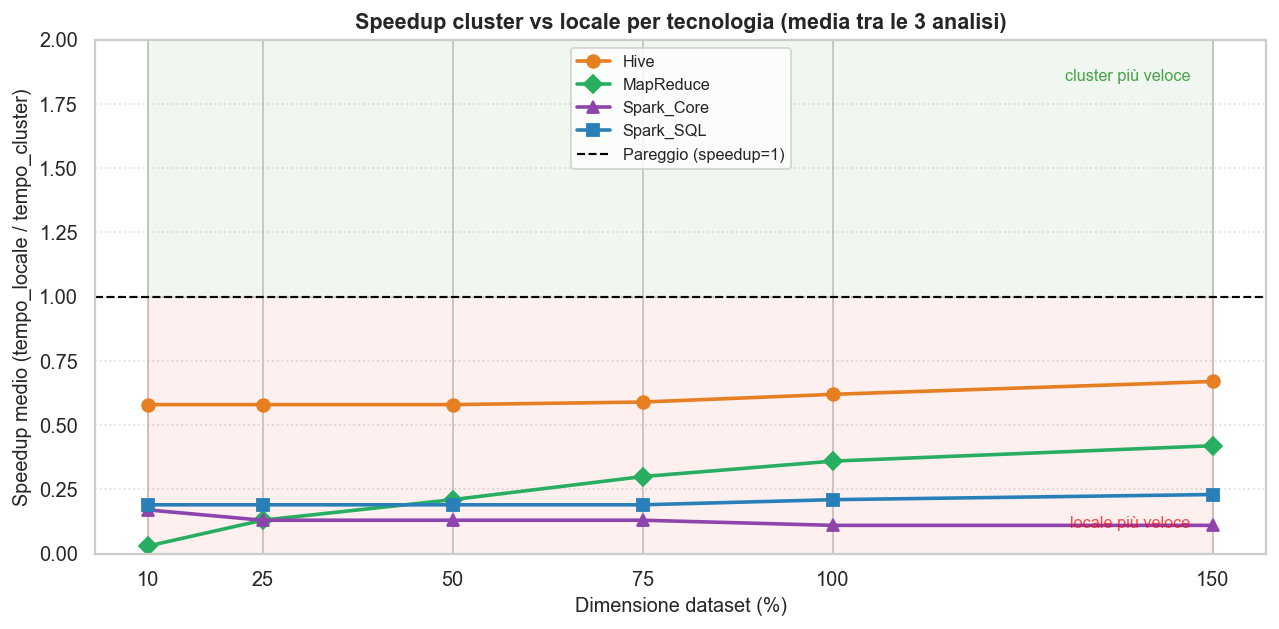

Salvato: charts/speedup_per_tech.png


In [9]:
sp_rows = []
for tech in TECNOLOGIE:
    for pct in PERCENTUALI:
        tl = df_loc[(df_loc['Tecnologia']==tech)&(df_loc['Pct']==pct)]['Tempo_Secondi']
        tc = df_clu[(df_clu['Tecnologia']==tech)&(df_clu['Pct']==pct)]['Tempo_Secondi']
        if not tl.empty and not tc.empty and tc.mean() > 0:
            sp_rows.append({'Tecnologia': tech, 'Pct': pct,
                            'Speedup_medio': round(tl.mean() / tc.mean(), 2)})

df_sp2 = pd.DataFrame(sp_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for tech in TECNOLOGIE:
    sub = df_sp2[df_sp2['Tecnologia']==tech].sort_values('Pct')
    if sub.empty:
        continue
    ax.plot(sub['Pct'], sub['Speedup_medio'],
            color=COLORS.get(tech,'gray'), marker=MARKERS.get(tech,'o'),
            linewidth=2, markersize=7, label=tech)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Pareggio (speedup=1)')

# ylim calcolato in modo sicuro PRIMA di fill_between
y_max = df_sp2['Speedup_medio'].max() * 1.15 if not df_sp2.empty else 3.0
y_max = max(y_max, 2.0)
ax.set_ylim(0, y_max)
ax.fill_between(PERCENTUALI, 0, 1, alpha=0.06, color='red')
ax.fill_between(PERCENTUALI, 1, y_max, alpha=0.06, color='green')

ax.set_xlabel('Dimensione dataset (%)', fontsize=11)
ax.set_ylabel('Speedup medio (tempo_locale / tempo_cluster)', fontsize=11)
ax.set_title('Speedup cluster vs locale per tecnologia (media tra le 3 analisi)',
             fontsize=12, fontweight='bold')
ax.set_xticks(PERCENTUALI)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.text(PERCENTUALI[-1]*0.98, y_max*0.92, 'cluster più veloce',
        ha='right', color='green', alpha=0.7, fontsize=9)
ax.text(PERCENTUALI[-1]*0.98, 0.1, 'locale più veloce',
        ha='right', color='red', alpha=0.7, fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'speedup_per_tech.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvato: {CHARTS_DIR}/speedup_per_tech.png')

## 9. Overhead di setup: breakeven point

Il cluster EMR richiede ~10 minuti di avvio + trasferimento dati S3→HDFS. Questo overhead si ammortizza solo su dataset sufficientemente grandi.

In [10]:
OVERHEAD_S = 600  # ~10 min avvio EMR + sync S3→HDFS

rows_be = []
for tech in TECNOLOGIE:
    for analisi in ANALISI:
        row_d = {'Tecnologia': tech, 'Analisi': f'A{analisi}'}
        for pct in PERCENTUALI:
            tl = df_loc[(df_loc['Tecnologia']==tech)&(df_loc['Analisi']==analisi)&(df_loc['Pct']==pct)]['Tempo_Secondi']
            tc = df_clu[(df_clu['Tecnologia']==tech)&(df_clu['Analisi']==analisi)&(df_clu['Pct']==pct)]['Tempo_Secondi']
            if not tl.empty and not tc.empty:
                saving = tl.values[0] - tc.values[0]
                row_d[f'{pct}%'] = '✅' if (saving - OVERHEAD_S) > 0 else '  '
            else:
                row_d[f'{pct}%'] = '-'
        rows_be.append(row_d)

df_be = pd.DataFrame(rows_be).set_index(['Tecnologia','Analisi'])
print(f'Breakeven con overhead stimato = {OVERHEAD_S}s ({OVERHEAD_S//60} min)')
print('✅ = cluster conveniente (risparmio > overhead setup)\n')
display(df_be)

Breakeven con overhead stimato = 600s (10 min)
✅ = cluster conveniente (risparmio > overhead setup)



10% 25% 50% 75% 100% 150%
Tecnologia Analisi                          
Hive       A3.1                             
           A3.2                             
           A3.3      -   -   -   -    -    -
MapReduce  A3.1                             
           A3.2                             
           A3.3                             
Spark_Core A3.1      -   -   -   -    -    -
           A3.2      -   -   -   -    -    -
           A3.3                             
Spark_SQL  A3.1                             
           A3.2                             
           A3.3

## 10. Riepilogo e conclusioni

In [11]:
df100_pivot = (
    df_all[df_all['Pct']==100]
    .pivot_table(index=['Analisi','Tecnologia'], columns='Ambiente', values='Tempo_Secondi')
    .reset_index()
)
df100_pivot.columns.name = None
df100_pivot['Speedup'] = (df100_pivot['Locale'] / df100_pivot['Cluster']).round(2)

print('=== Speedup al 100% del dataset ===')
display(df100_pivot[['Analisi','Tecnologia','Locale','Cluster','Speedup']]
        .sort_values('Speedup', ascending=False)
        .set_index(['Analisi','Tecnologia']))

best  = df100_pivot.loc[df100_pivot['Speedup'].idxmax()]
worst = df100_pivot.loc[df100_pivot['Speedup'].idxmin()]
print()
print(f'Massimo speedup: {best["Speedup"]:.2f}x  →  Analisi {best["Analisi"]} / {best["Tecnologia"]}')
print(f'Minimo speedup:  {worst["Speedup"]:.2f}x  →  Analisi {worst["Analisi"]} / {worst["Tecnologia"]}')
print(f'Speedup medio globale: {df100_pivot["Speedup"].mean():.2f}x')

=== Speedup al 100% del dataset ===


Locale  Cluster  Speedup
Analisi Tecnologia                          
3.2     Hive          38.0     48.0     0.79
        MapReduce     21.0     48.0     0.44
3.1     Hive          12.0     33.0     0.36
        MapReduce     14.0     43.0     0.33
3.3     MapReduce     15.0     48.0     0.31
3.2     Spark_SQL     11.0     50.0     0.22
3.3     Spark_SQL      6.0     28.0     0.21
3.1     Spark_SQL      5.0     28.0     0.18
3.3     Spark_Core     6.0     55.0     0.11


Massimo speedup: 0.79x  →  Analisi 3.2 / Hive
Minimo speedup:  0.11x  →  Analisi 3.3 / Spark_Core
Speedup medio globale: 0.33x


---

## Conclusioni

### Correttezza
I risultati del cluster AWS EMR sono **identici** (o equivalenti entro arrotondamento float ±0.01) a quelli locali per tutti e 9 i job. Questo conferma la correttezza delle implementazioni sia in ambiente single-node che distribuito.

### Performance

| Aspetto | Osservazione |
|---|---|
| **Scalabilità** | Il cluster scala linearmente con la dimensione del dataset; il locale degrada più rapidamente su dataset grandi |
| **Piccoli dataset (10-25%)** | Il locale è più veloce — l'overhead YARN e la serializzazione di rete penalizzano il cluster |
| **Dataset grandi (75-150%)** | Il cluster diventa conveniente quando il parallelismo compensa l'overhead di scheduling |
| **MapReduce** | Beneficia maggiormente del cluster — Hadoop Streaming su YARN distribuisce davvero il carico sui nodi core |
| **Spark SQL / Core** | Già ottimizzati in locale (Catalyst + codegen), lo speedup cluster è più contenuto |
| **Hive** | Overhead Tez in cluster; su dataset piccoli il locale embedded è più reattivo |

### Raccomandazione
Il cluster AWS EMR conviene quando:
- il dataset supera i **75%** (~268 MB, ~5M righe)
- si eseguono **batch di molte analisi** (l'overhead di setup si ammortizza)
- si ha bisogno di **fault tolerance** o si vuole liberare il laptop durante l'esecuzione

Per analisi singole su dataset piccoli (< 50%), l'ambiente locale è più veloce e non richiede costi AWS.